# Oslo Bysykkel: Feature Engineering and Model Training

Loads the merged hourly dataset, engineers all features, then trains and evaluates two XGBoost regressors: one for week days (Mon–Fri) and one for weekends (Sat–Sun).

**Input:** `output/merged_hourly.csv`  
**Output:** `output/model_weekday.joblib`, `output/model_weekend.joblib`

## 0 · Configuration

In [1]:
from pathlib import Path

INPUT_PATH    = Path("output/merged_hourly.csv")
HOLIDAYS_PATH = Path("input/oslo_holidays_2020_2027.csv")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1 · Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

## 2 · Load merged hourly data

In [3]:
df = pd.read_csv(INPUT_PATH, parse_dates=["hour"])
df = df.sort_values("hour").reset_index(drop=True)

print(f"Loaded {len(df):,} rows  ({df['hour'].min()} → {df['hour'].max()})")
print(f"Columns: {df.columns.tolist()}")

Loaded 43,332 rows  (2020-03-18 00:00:00 → 2026-03-03 19:00:00)
Columns: ['hour', 'trip_count', 'avg_duration_min', 'median_duration_min', 'temp_c', 'precip_mm', 'wind_speed_ms', 'cloud_area_fraction', 'date', 'hour_of_day', 'day_of_week', 'is_weekend', 'month']


## 3 · Cyclical encoding

Hour-of-day, month, and day-of-year are all circular: hour 23 is one step from hour 0, not 23 steps away. Encoding them as sin/cos pairs preserves that continuity for the model, unlike raw integer values.

In [4]:
def cyclical(series: pd.Series, period: int):
    """Return sin and cos encodings for a circular feature."""
    radians = 2 * np.pi * series / period
    return np.sin(radians), np.cos(radians)

# Hour of day (period 24)
df["hour_sin"], df["hour_cos"] = cyclical(df["hour_of_day"], 24)

# Month (period 12)
df["month_sin"], df["month_cos"] = cyclical(df["month"], 12)

# Day of year (period 365) — finer seasonal resolution than month
df["day_of_year"] = df["hour"].dt.dayofyear
df["doy_sin"], df["doy_cos"] = cyclical(df["day_of_year"], 365)

print("Cyclical features added.")

Cyclical features added.


### 3a · Visualise cyclical encoding

A quick sanity check, plotting the sin/cos pairs should trace smooth circles.

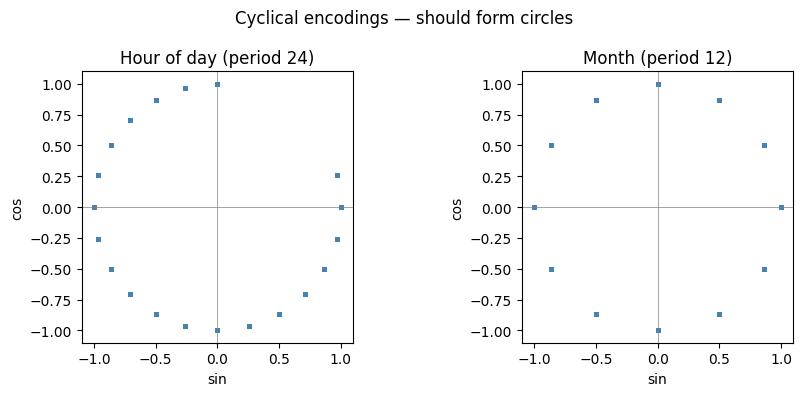

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

pairs = [
    ("hour_sin",  "hour_cos",  "Hour of day (period 24)"),
    ("month_sin", "month_cos", "Month (period 12)"),
]

for ax, (s_col, c_col, title) in zip(axes, pairs):
    ax.scatter(df[s_col], df[c_col], alpha=0.05, s=6, color="steelblue")
    ax.set_xlabel("sin")
    ax.set_ylabel("cos")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)

plt.suptitle("Cyclical encodings — should form circles", fontsize=12)
plt.tight_layout()
plt.show()

## 4 · Lag features

A 1-hour lag of `precip_mm` captures recent weather momentum: whether it has been raining in the hour leading up to a given slot. The hypothesis is that this might affect Bysykkel usage. This lag is available at forecast time since it is derived from the weather forecast itself. 

Previously we also experimented with other lag variables (including short-term `trip_count` lags), but we decided to leave them out here because they did not add much value or because they would not be available when forecasting usage days ahead. 

In [6]:
df["precip_mm_lag1h"] = df["precip_mm"].shift(1)
print(f"Added precip_mm_lag1h  ({df['precip_mm_lag1h'].isna().sum()} NaN rows to drop)")

Added precip_mm_lag1h  (142 NaN rows to drop)


### 4a · Drop rows with NaN lag values

The first row will be missing the 1h lag — drop it so the training set is fully populated.

In [7]:
before = len(df)
df = df.dropna(subset=["precip_mm_lag1h"]).reset_index(drop=True)
print(f"Dropped {before - len(df):,} rows with NaN lag values  ({len(df):,} remaining)")

Dropped 142 rows with NaN lag values  (43,190 remaining)


In [8]:
# Oslo school holidays & national holidays
holidays_csv = pd.read_csv(HOLIDAYS_PATH)
holidays_csv["date"] = pd.to_datetime(holidays_csv["date"], format="%d-%m-%Y").dt.date
_school_holiday_dates   = set(holidays_csv.loc[holidays_csv["oslo_school_holiday"],   "date"])
_national_holiday_dates = set(holidays_csv.loc[holidays_csv["national_holiday"],      "date"])

df["is_school_holiday"]   = df["hour"].dt.date.map(lambda d: int(d in _school_holiday_dates))
df["is_national_holiday"] = df["hour"].dt.date.map(lambda d: int(d in _national_holiday_dates))

flag_cols = ["is_school_holiday", "is_national_holiday"]

print("Holiday flag value counts:")
print(df[flag_cols].sum().rename("n_true").to_frame().assign(
    pct=lambda x: (100 * x["n_true"] / len(df)).round(1)
))

Holiday flag value counts:
                     n_true   pct
is_school_holiday     10681  24.7
is_national_holiday    1361   3.2


## 5a · Remove service closure hours

Bysykkel is closed every day from 01:00 to 04:59 Oslo local time, i.e. no trips can be started between those hours. These rows are excluded from training so the model never learns on near-zero targets caused by a hard operational constraint rather than any weather or calendar signal. At forecast time the same hours are set to zero directly (without running the model).

In [9]:
CLOSED_HOURS = [1, 2, 3, 4]   # 01:00–04:59 Oslo time

before = len(df)
df = df[~df["hour_of_day"].isin(CLOSED_HOURS)].reset_index(drop=True)
print(f"Removed {before - len(df):,} service-closure rows  ({len(df):,} remaining)")

Removed 0 service-closure rows  (43,190 remaining)


In [10]:
# Total trips in the previous calendar year
# This is the only trip-count-derived feature used: it captures the
# year-on-year growth trend and is always fully available at forecast time.
annual = (
    df.groupby(df["hour"].dt.year)["trip_count"]
    .sum()
    .reset_index()
    .rename(columns={"hour": "year", "trip_count": "prev_year_trips"})
)
annual["year"] += 1   # shift: 2022 total becomes the feature for 2023
df["year"] = df["hour"].dt.year
df = df.merge(annual, on="year", how="left").drop(columns="year")

# Drop the first calendar year (no previous year available)
before = len(df)
df = df.dropna(subset=["prev_year_trips"]).reset_index(drop=True)
print(f"Dropped {before - len(df):,} rows missing prev_year_trips  ({len(df):,} remaining)")
print(f"\nprev_year_trips value counts by year:")
print(df.groupby(df["hour"].dt.year)["prev_year_trips"].first())

Dropped 5,771 rows missing prev_year_trips  (37,419 remaining)

prev_year_trips value counts by year:
hour
2021    1694414.0
2022    1417955.0
2023    1284915.0
2024    1080933.0
2025    1142197.0
2026    1112055.0
Name: prev_year_trips, dtype: float64


## 6 · Final feature set overview

In [11]:
feature_cols = (
    # Raw weather
    ["temp_c", "precip_mm", "wind_speed_ms", "cloud_area_fraction"]
    # Calendar
    + ["hour_of_day", "day_of_week"]
    # Cyclical encodings
    + ["hour_sin", "hour_cos", "month_sin", "month_cos", "doy_sin", "doy_cos"]
    # 1-hour precipitation lag
    + ["precip_mm_lag1h"]
    # Previous year total trips (growth trend — always available)
    + ["prev_year_trips"]
    # Holiday flags
    + flag_cols
)

# Keep only columns that actually exist
feature_cols = [c for c in feature_cols if c in df.columns]

print(f"Target   : trip_count")
print(f"Features : {len(feature_cols)}")
print()
for col in feature_cols:
    null_pct = 100 * df[col].isna().mean()
    print(f"  {col:<35} dtype={str(df[col].dtype):<12} nulls={null_pct:.1f}%")

Target   : trip_count
Features : 16

  temp_c                              dtype=float64      nulls=0.0%
  precip_mm                           dtype=float64      nulls=0.0%
  wind_speed_ms                       dtype=float64      nulls=0.0%
  cloud_area_fraction                 dtype=float64      nulls=0.0%
  hour_of_day                         dtype=int64        nulls=0.0%
  day_of_week                         dtype=int64        nulls=0.0%
  hour_sin                            dtype=float64      nulls=0.0%
  hour_cos                            dtype=float64      nulls=0.0%
  month_sin                           dtype=float64      nulls=0.0%
  month_cos                           dtype=float64      nulls=0.0%
  doy_sin                             dtype=float64      nulls=0.0%
  doy_cos                             dtype=float64      nulls=0.0%
  precip_mm_lag1h                     dtype=float64      nulls=0.0%
  prev_year_trips                     dtype=float64      nulls=0.0%
  is_school

### 6a · Correlation of engineered features with trip_count

In [12]:
from scipy import stats

print(f"{'Feature':<30} {'Pearson r':>10}  {'p-value':>10}  sig")
print("─" * 58)
for col in feature_cols:
    sub = df[["trip_count", col]].dropna()
    r, p = stats.pearsonr(sub[col], sub["trip_count"])
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{col:<30} {r:>+10.3f}  {p:>10.4f}  {stars}")

Feature                         Pearson r     p-value  sig
──────────────────────────────────────────────────────────
temp_c                             +0.633      0.0000  ***
precip_mm                          -0.072      0.0000  ***
wind_speed_ms                      +0.107      0.0000  ***
cloud_area_fraction                -0.117      0.0000  ***
hour_of_day                        +0.126      0.0000  ***
day_of_week                        -0.128      0.0000  ***
hour_sin                           -0.204      0.0000  ***
hour_cos                           -0.225      0.0000  ***
month_sin                          -0.346      0.0000  ***
month_cos                          -0.476      0.0000  ***
doy_sin                            -0.214      0.0000  ***
doy_cos                            -0.552      0.0000  ***
precip_mm_lag1h                    -0.054      0.0000  ***
prev_year_trips                    +0.112      0.0000  ***
is_school_holiday                  +0.112      0.0000  *

## 7 · Save

In [13]:
out_cols  = ["hour", "trip_count"] + feature_cols
out_path  = OUTPUT_DIR / "features_hourly.csv"
df[out_cols].to_csv(out_path, index=False)

print(f"Saved → {out_path.resolve()}")
print(f"Shape  : {df.shape[0]:,} rows × {len(out_cols)} columns")

Saved → /Users/dylan/Projects/BysykkelForecast/output/features_hourly.csv
Shape  : 37,419 rows × 18 columns


---

## Part 2 · Model Training

Two XGBoost regressors are trained separately for weekday and weekend hours, tuned with `RandomizedSearchCV` using time-series cross-validation, and evaluated on a final test set not seen before by the model.

In [14]:
import warnings
warnings.filterwarnings("ignore")
import joblib
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats             import randint, uniform
from xgboost                 import XGBRegressor

N_SPLITS  = 5          # number of rolling CV folds
TEST_SIZE = 24 * 30    # ~1 month of hours per fold

## 3 · Define features and target

`hour` is the index, `trip_count` is the target. Remaining columns are used as features.

In [15]:
TARGET = "trip_count"
FEATURE_COLS = feature_cols   # defined in Part 1

X = df[FEATURE_COLS].values
y = df[TARGET].values

print(f"Features : {len(FEATURE_COLS)}")
print(f"Samples  : {len(y):,}")
print(f"Target   : min={y.min():.0f}  max={y.max():.0f}  mean={y.mean():.1f}")
print(f"\nFeature list:")
for c in FEATURE_COLS:
    print(f"  {c}")

Features : 16
Samples  : 37,419
Target   : min=1  max=1029  mean=161.9

Feature list:
  temp_c
  precip_mm
  wind_speed_ms
  cloud_area_fraction
  hour_of_day
  day_of_week
  hour_sin
  hour_cos
  month_sin
  month_cos
  doy_sin
  doy_cos
  precip_mm_lag1h
  prev_year_trips
  is_school_holiday
  is_national_holiday


## 4 · Cross-validation setup

We use `TimeSeriesSplit` with a fixed `test_size` so every fold evaluates on the same number of hours (~1 month). Each fold trains on all data before the test window, no shuffling, no leakage.

In [16]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)

# Preview fold sizes
print(f"{'Fold':<6} {'Train hours':>12}  {'Test hours':>12}")
print("─" * 34)
for fold, (tr, te) in enumerate(tscv.split(X), 1):
    print(f"{fold:<6} {len(tr):>12,}  {len(te):>12,}")

Fold    Train hours    Test hours
──────────────────────────────────
1            33,819           720
2            34,539           720
3            35,259           720
4            35,979           720
5            36,699           720


In [17]:
def mape(y_true, y_pred, eps=1e-6):
    """Mean Absolute Percentage Error, guarded against zero actuals."""
    mask = np.abs(y_true) > eps
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def evaluate(y_true, y_pred) -> dict:
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
    }

## 5 · Define models

Two XGBoost regressors with identical starting hyperparameters are prepared. One trained exclusively on weekday hours (Mon–Fri) and one on weekend hours (Sat–Sun). Although XGBoost should be able to learn the distinct week day and weekend patterns by include an "is_weekend" flag, since the two patterns are so different it should be computationally cheaper to have two separate models. 

In earlier versions of this notebook we also experimented with linear regression, random forests and traditional gradient boosting, which were outperformed by XGBoost. We keep only the XGBoost models here for simplicity. 

In [18]:
# Day-type masks (numpy bool arrays for clean indexing)
mask_weekday = df["day_of_week"].isin([0, 1, 2, 3, 4]).values
mask_weekend = ~mask_weekday

X_weekday, y_weekday = X[mask_weekday], y[mask_weekday]
X_weekend, y_weekend = X[mask_weekend], y[mask_weekend]

print(f"Weekday samples : {mask_weekday.sum():,}")
print(f"Weekend samples : {mask_weekend.sum():,}")

XGB_PARAMS = dict(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

MODELS = {
    "Weekday": XGBRegressor(**XGB_PARAMS),
    "Weekend": XGBRegressor(**XGB_PARAMS),
}
SPLITS = {
    "Weekday": (X_weekday, y_weekday),
    "Weekend": (X_weekend, y_weekend),
}

Weekday samples : 26,756
Weekend samples : 10,663


## 7 · Hyperparameter tuning

Both models are tuned independently using `RandomizedSearchCV` with the same `TimeSeriesSplit`. A held-out final test set is set aside before tuning, so we're left with data not seen by the model to give us an idea of real-world performance. 

In [19]:
HOLDOUT_HOURS = 24 * 90
n = len(df)

dev_idx  = np.arange(n) < (n - HOLDOUT_HOURS)
test_idx = ~dev_idx

X_dev_weekday,  y_dev_weekday  = X[dev_idx  & mask_weekday], y[dev_idx  & mask_weekday]
X_dev_weekend,  y_dev_weekend  = X[dev_idx  & mask_weekend],  y[dev_idx  & mask_weekend]
X_test_weekday, y_test_weekday = X[test_idx & mask_weekday], y[test_idx & mask_weekday]
X_test_weekend, y_test_weekend = X[test_idx & mask_weekend],  y[test_idx & mask_weekend]

hours_test_weekday = df["hour"].values[test_idx & mask_weekday]
hours_test_weekend = df["hour"].values[test_idx & mask_weekend]

print(f"Dev   weekday : {len(y_dev_weekday):,}  |  test weekday : {len(y_test_weekday):,}")
print(f"Dev   weekend : {len(y_dev_weekend):,}  |  test weekend : {len(y_test_weekend):,}")
print(f"Final test window: {df['hour'].iloc[-HOLDOUT_HOURS].date()} → {df['hour'].iloc[-1].date()}")

Dev   weekday : 25,229  |  test weekday : 1,527
Dev   weekend : 10,030  |  test weekend : 633
Final test window: 2025-11-15 → 2026-03-03


In [20]:
tscv_tune = TimeSeriesSplit(n_splits=3, test_size=TEST_SIZE)

PARAM_DIST = {
    "n_estimators":     randint(100, 600),
    "learning_rate":    uniform(0.01, 0.2),
    "max_depth":        randint(3, 8),
    "min_child_weight": randint(2, 20),
    "subsample":        uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.5, 0.5),
}

DEV_SPLITS = {
    "Weekday": (X_dev_weekday, y_dev_weekday),
    "Weekend": (X_dev_weekend, y_dev_weekend),
}

tuned_models = {}
for name, (Xi_dev, yi_dev) in DEV_SPLITS.items():
    print(f"  Tuning {name} XGBoost...", end=" ", flush=True)
    search = RandomizedSearchCV(
        XGBRegressor(random_state=42, verbosity=0),
        param_distributions=PARAM_DIST,
        n_iter=30,
        cv=tscv_tune,
        scoring="neg_mean_absolute_error",
        random_state=42,
        n_jobs=-1,
        refit=True,
    )
    search.fit(Xi_dev, yi_dev)
    tuned_models[name] = search.best_estimator_
    print(f"done  (best CV MAE: {-search.best_score_:.1f})  params: {search.best_params_}")

  Tuning Weekday XGBoost... done  (best CV MAE: 30.0)  params: {'colsample_bytree': np.float64(0.6654490124263246), 'learning_rate': np.float64(0.02271167005720473), 'max_depth': 7, 'min_child_weight': 4, 'n_estimators': 271, 'subsample': np.float64(0.8550229885420852)}
  Tuning Weekend XGBoost... done  (best CV MAE: 22.0)  params: {'colsample_bytree': np.float64(0.5852620618436457), 'learning_rate': np.float64(0.023010318597055907), 'max_depth': 6, 'min_child_weight': 15, 'n_estimators': 341, 'subsample': np.float64(0.7541666010159664)}


### 7a · Feature importance

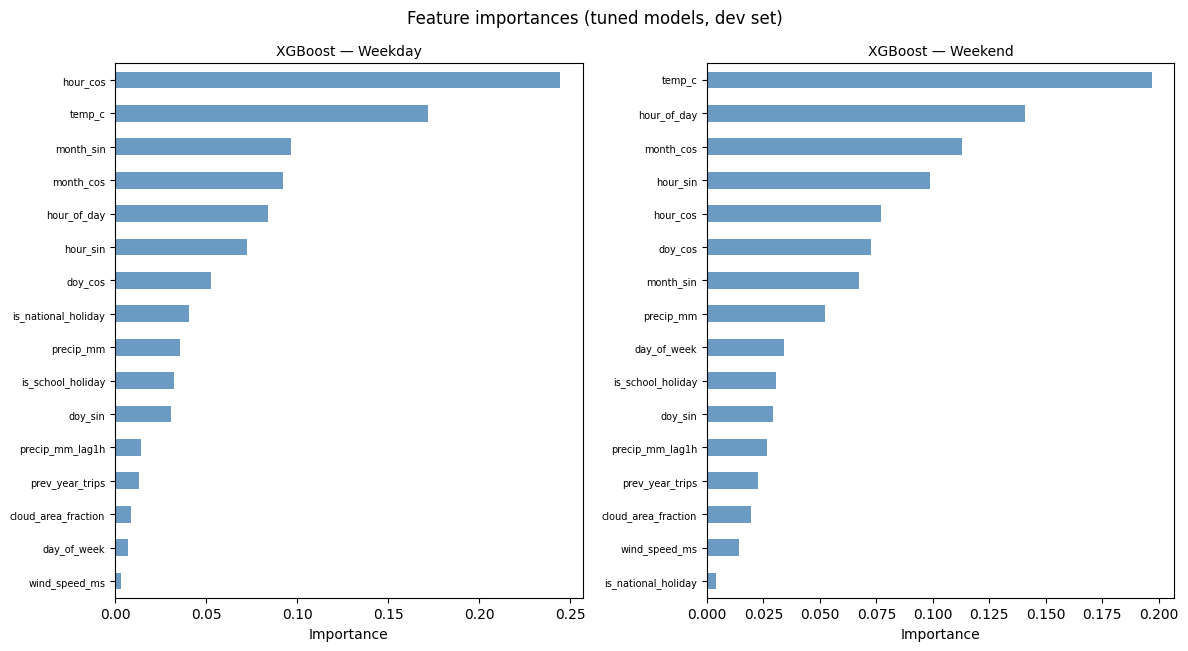

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 0.35 * len(FEATURE_COLS) + 1))

for ax, (name, model) in zip(axes, tuned_models.items()):
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    imp.plot.barh(ax=ax, color="steelblue", alpha=0.8)
    ax.set_title(f"XGBoost — {name}", fontsize=10)
    ax.set_xlabel("Importance")
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Feature importances (tuned models, dev set)", fontsize=12)
plt.tight_layout()
plt.show()

We can see some clear differences in feature performance, week days vs. weekend days. Note for example that is_national_holiday adds little information for weekends, which makes sense as most people are off from work on the weekend anyway (unlike week days). As expected, temperature is highly informative for the model, being the first feature on weekend days and the second one on week days. Hour of day seems to play a more important role on week days, when people are stuck to their work schedules. 

### 7b · Evaluate tuned models on final test set

In [22]:
TEST_DATA = {
    "Weekday": (X_test_weekday, y_test_weekday),
    "Weekend": (X_test_weekend, y_test_weekend),
}

print(f"{'Model':<10} {'MAE':>8}  {'RMSE':>8}  {'R²':>8}  {'MAPE':>8}")
print("─" * 50)
final_metrics = {}
for name, (Xi_test, yi_test) in TEST_DATA.items():
    preds = np.clip(tuned_models[name].predict(Xi_test), 0, None)
    m = evaluate(yi_test, preds)
    final_metrics[name] = m
    print(f"{name:<10} {m['MAE']:>8.1f}  {m['RMSE']:>8.1f}  {m['R2']:>8.3f}  {m['MAPE']:>7.1f}%")

Model           MAE      RMSE        R²      MAPE
──────────────────────────────────────────────────
Weekday        11.6      18.0     0.850     52.9%
Weekend         7.8      11.5     0.767     69.9%


**Note:** the current test set runs from late November to early March, which is not exactly the most popular time of year for cycling. The small usage number probably means that the MAE presented here is lower than it would be in busier months. It will be interesting to see how the test performance here compares to forecast performance over the coming (summer) months. 

**Also note:** our model only can only learn from basic calendar and weather features, but in reality there are many more reasons why people might chose to take a Bysykkel (or not). The elephant in the room being service availability of Bysykkel (as well as other transport providers). People cannot take a Bysykkel if no Bysykkels are available. Similarly, more people will want to take a Bysykkel if public transport is disrupted, regardless of the weather. Such information was not incorporated in the model here. An important limitation, and a good opportunity to improve the model if such data can be obtained. 

### 7c · Actual vs predicted — final test set

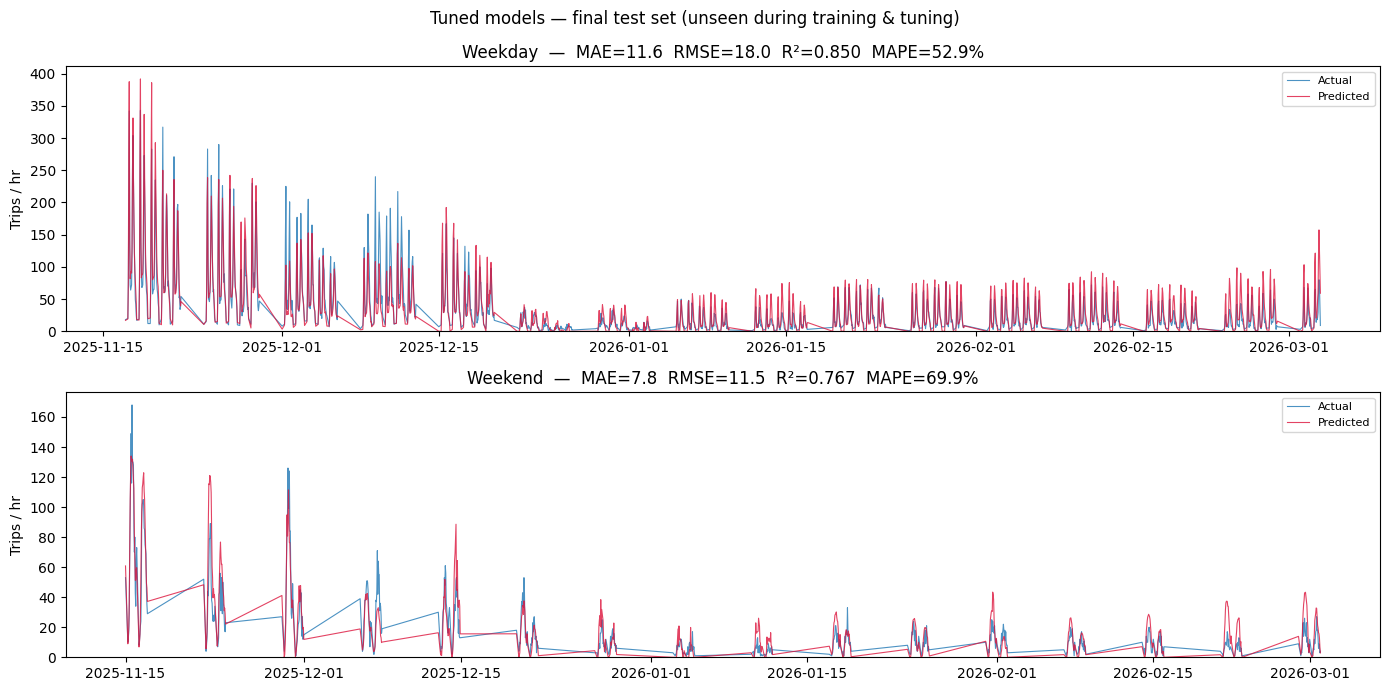

In [23]:
HOURS_TEST = {
    "Weekday": hours_test_weekday,
    "Weekend": hours_test_weekend,
}

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, name in zip(axes, ["Weekday", "Weekend"]):
    Xi_test, yi_test = TEST_DATA[name]
    preds = np.clip(tuned_models[name].predict(Xi_test), 0, None)
    m = final_metrics[name]
    ax.plot(HOURS_TEST[name], yi_test, lw=0.8, alpha=0.8, label="Actual")
    ax.plot(HOURS_TEST[name], preds,   lw=0.8, alpha=0.8, color="crimson", label="Predicted")
    ax.set_ylabel("Trips / hr")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{name}  —  MAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  R²={m['R2']:.3f}  MAPE={m['MAPE']:.1f}%")
    ax.legend(fontsize=8)

plt.suptitle("Tuned models — final test set (unseen during training & tuning)", fontsize=12)
plt.tight_layout()
plt.show()

## 8 · Save models

Save tuned models to disk so we can load and use them for operational forecasts. 

In [24]:
for name, (Xi_all, yi_all) in SPLITS.items():
    model = tuned_models[name]
    model.fit(Xi_all, yi_all)
    path = OUTPUT_DIR / f"model_{name.lower()}.joblib"
    joblib.dump({"model": model, "features": FEATURE_COLS, "name": f"XGBoost {name}"}, path)
    print(f"Saved {name} → {path}  (test MAE: {final_metrics[name]['MAE']:.1f})")

Saved Weekday → output/model_weekday.joblib  (test MAE: 11.6)
Saved Weekend → output/model_weekend.joblib  (test MAE: 7.8)
